In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import seaborn as sns
import numpy as np
import math

pd.set_option('display.max_columns', None)

output_folder_boxplot = 'boxplots'
output_folder_histogram = 'histograms'
output_folder_pie = 'pies'

if not os.path.exists(output_folder_boxplot):
    os.makedirs(output_folder_boxplot)
if not os.path.exists(output_folder_histogram):
    os.makedirs(output_folder_histogram)
if not os.path.exists(output_folder_pie):
    os.makedirs(output_folder_pie)

In [ ]:
with open('spambase.names') as f:
    lines = f.readlines()

column_names = [line.split(':')[0] for line in lines if 'continuous.' in line]
column_names.append('spam')

df = pd.read_csv('spambase.data', header=None, names=column_names)

X = df.drop('spam', axis=1)
y = df['spam']

In [ ]:
print(X.describe())
print(X.skew())
print('Braki w danych: ', df.isnull().sum().sum())
desc = X.describe()
skew_vals = X.skew()
desc.loc['skew'] = skew_vals

folder = 'wykresy2'
os.makedirs(folder, exist_ok=True)
columns_per_table = 10
num_tables = math.ceil(desc.shape[1] / columns_per_table)

for i in range(num_tables):
        start_col = i * columns_per_table
        end_col = min((i+1)*columns_per_table, desc.shape[1])
        sub_desc = desc.iloc[:, start_col:end_col]

        fig, ax = plt.subplots(figsize = (len(sub_desc.columns)*1.2, 2.5))
        ax.axis('off')



        table = plt.table(cellText=sub_desc.round(2).values, colLabels=sub_desc.columns, rowLabels=sub_desc.index, cellLoc='center', loc='center', bbox=[0,0,1,0.9])
        table.auto_set_font_size(False)
        table.set_fontsize(7)
        table.scale(1.0, 1.0)

        ax.text(0.5, 0.93, f'Statystyki opisowe cech {start_col + 1} - {end_col}', ha='center', va='bottom', fontsize=12, transform=fig.transFigure)

        filename = os.path.join(folder, f'statystyki_opisowe_{i+1}.png')
        plt.savefig(filename, bbox_inches='tight',dpi=300)
        plt.close()

       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count    4601.000000     4601.000000       4601.000000         4601.000000   
mean        0.312223        0.095901          0.114208            0.105295   
std         0.672513        0.273824          0.391441            0.401071   
min         0.000000        0.

In [ ]:
for col in df.columns:
    if col == 'spam':
        counts = df[col].value_counts()
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
        ax.set_title(f'Wykres kołowy: {col}')
        plt.tight_layout()

        fig.savefig(os.path.join(output_folder_pie, f'pie_{col}.png'))
        plt.close(fig)
        continue

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(X[col], bins=30, color='skyblue', edgecolor='black')
    ax.grid(axis='y', linestyle='-', alpha=0.6)
    ax.set_title(f'Histogram: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Liczba')
    plt.tight_layout()

    fig.savefig(os.path.join(output_folder_histogram, f'histogram_{col}.png'))
    plt.close(fig)


    fig, ax = plt.subplots(figsize=(6, 4))
    box = ax.boxplot(df[col],
                     flierprops=dict(marker='o', markersize=2, color='black', alpha=0.5))
    median = df[col].median()
    mean = df[col].mean()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    ax.axhline(median, color='red', linestyle='--', label='Mediana')  # Mediana
    ax.axhline(mean, color='green', linestyle='-', alpha=0.6, label='Średnia')  # Średnia
    ax.axhline(q1, color='purple', linestyle='dotted', alpha=0.7, label='Q1 (25%)')  # 1. kwartyl
    ax.axhline(q3, color='brown', linestyle='dotted', alpha=0.7, label='Q3 (75%)')  # 3. kwartyl
    ax.grid(axis='y', linestyle='-', alpha=0.6)

    ax.set_title(f'Boxplot: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Wartości')
    ax.legend()
    plt.tight_layout()

    fig.savefig(os.path.join(output_folder_boxplot, f'boxplot_{col}.png'))
    plt.close(fig)

In [ ]:
for col in X.columns:
    X[col] = np.log1p(X[col])

In [ ]:
scaler = StandardScaler()   # wymagany dla KNN i SVM, innym nie przeszkadza
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

In [ ]:
dd = pd.read_csv('wiersze.txt', header=None)
dd.columns = column_names
X_example = dd.drop('spam', axis = 1)
Y_example = dd['spam']

X_example_scaled = scaler.fit_transform(X_example)
X_example_scaled_df = pd.DataFrame(X_example_scaled, columns=X_example.columns)

In [ ]:
#Drzewa Decyzyjne
#Las losowy
#SVM
#KNN - las to w sumie bardziej zaawansowane drzewa decyzyjne wiec dodaje to zeby miec sensowne modele do hybrydowego (PS. chyba za duzo to nie zmieniło)

In [ ]:
def evaluation(model):
  pred = model.predict(X_test)
  proba = model.predict_proba(X_test)[:, 1]
  print(f"--- Ocena ---")
  print(f"Accuracy: {accuracy_score(y_test, pred):.4f}")
  print(f"F1 Score: {f1_score(y_test, pred):.4f}")
  print(f"AUC: {roc_auc_score(y_test, proba):.4f}")
  print("\nClassification Report\n", classification_report(y_test, pred))

  cm = confusion_matrix(y_test, pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
  plt.xlabel("Przewidziane etykiety")
  plt.ylabel("Prawdziwe etykiety")
  plt.title("Macierz Pomyłek")
  plt.show()

def validation(model, scoring):
  scores = cross_val_score(model, X_scaled_df, y, scoring=scoring)
  print(f"\n--- Walidacja Krzyzowa ---")
  print(f"Scores: {scores}")
  print(f"Mean {scoring}: {np.mean(scores):.4f}")
  print(f"Std Dev {scoring}: {np.std(scores):.4f}")

In [ ]:
def evaluation_example(model):
  pred = model.predict(X_example_scaled_df)
  proba = model.predict_proba(X_example_scaled_df)[:, 1]
  print(f"--- Ocena ---")
  print(f"Accuracy: {accuracy_score(Y_example, pred):.4f}")
  print(f"F1 Score: {f1_score(Y_example, pred):.4f}")
  print(f"AUC: {roc_auc_score(Y_example, proba):.4f}")
  print("\nClassification Report\n", classification_report(Y_example, pred))

  cm = confusion_matrix(Y_example, pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
  plt.xlabel("Przewidziane etykiety")
  plt.ylabel("Prawdziwe etykiety")
  plt.title("Macierz Pomyłek")
  plt.show()


Najlepsze parametry dla Drzewa Decyzyjnego: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Najlepszy wynik AUC dla Drzewa Decyzyjnego: 0.9549
--- Ocena ---
Accuracy: 0.8986
F1 Score: 0.8789
AUC: 0.8976

Classification Report
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       804
           1       0.88      0.88      0.88       577

    accuracy                           0.90      1381
   macro avg       0.90      0.90      0.90      1381
weighted avg       0.90      0.90      0.90      1381



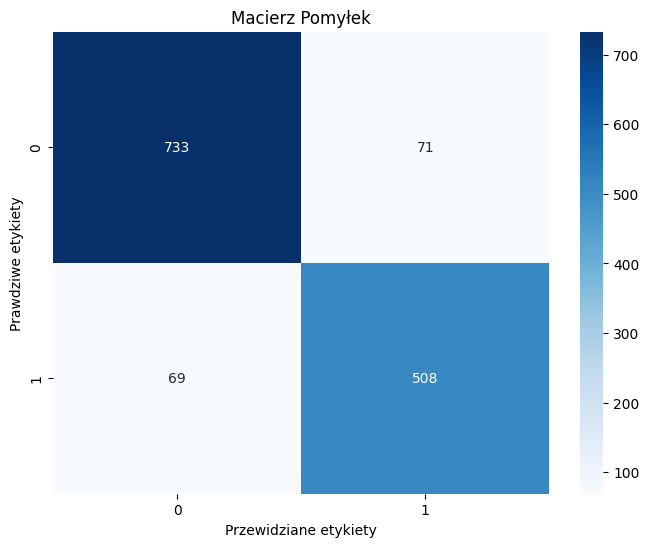

--- Ocena ---
Accuracy: 0.9117
F1 Score: 0.8899
AUC: 0.9627

Classification Report
               precision    recall  f1-score   support

           0       0.90      0.95      0.93       804
           1       0.93      0.85      0.89       577

    accuracy                           0.91      1381
   macro avg       0.91      0.90      0.91      1381
weighted avg       0.91      0.91      0.91      1381



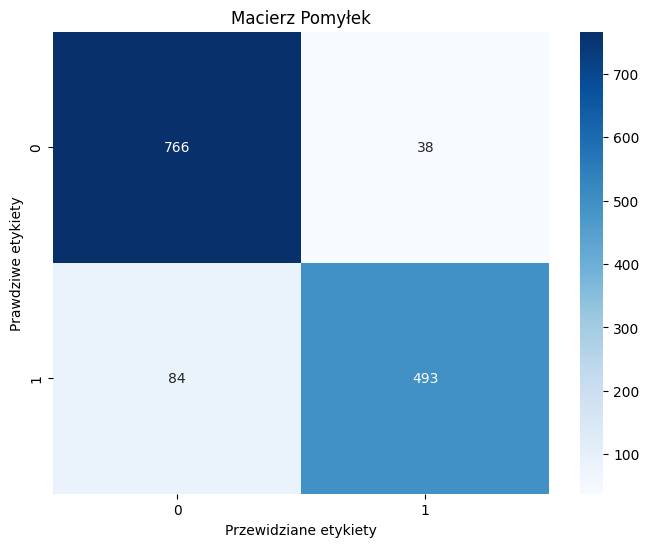

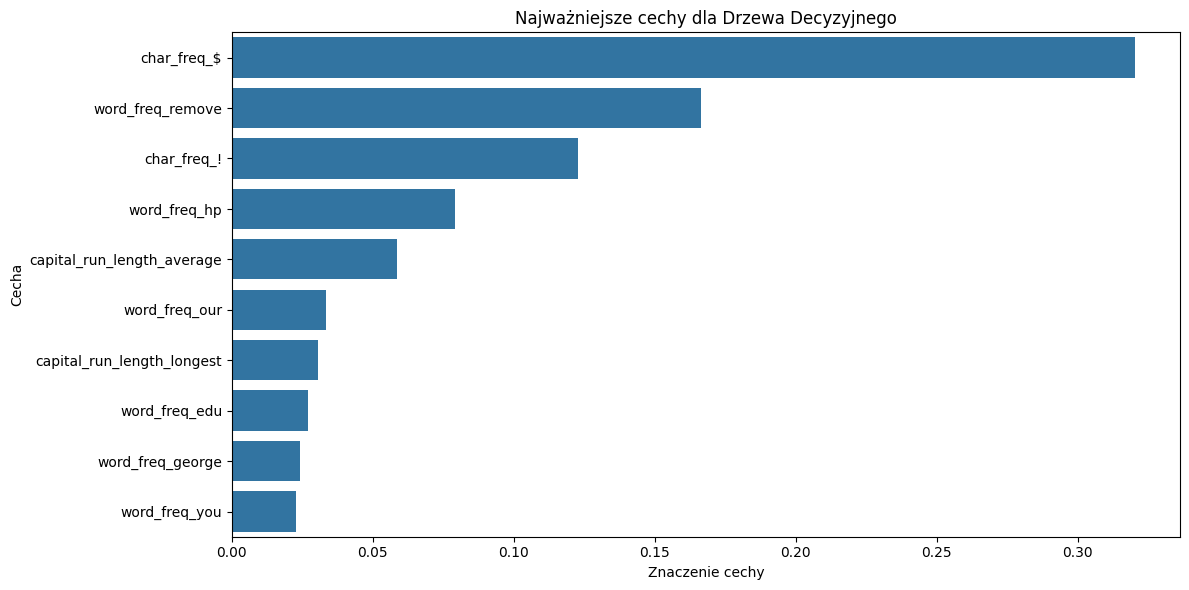


--- Walidacja Krzyzowa ---
Scores: [0.95301747 0.95280205 0.958193   0.97489059 0.87878225]
Mean roc_auc: 0.9435
Std Dev roc_auc: 0.0334


In [ ]:
#Drzewo
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -------------------- #
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

### ---tuning------------------------------
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, 30, None],     #Maksymalna głębokość drzewa                          Głębokie drzewa są podatne na przeuczenie
    'min_samples_split': [2, 5, 10, 20],              #Minimalna liczba próbek aby podzielić węzeł          Zapobiega tworzeniu zbyt małych i specyficznych węzłów
    'min_samples_leaf': [1, 2, 5, 10],                #Minimalna liczba próbek, aby węzeł był liściem       kontroluje rozrost drzewa i pomaga w zapobieganiu przeuczeniu
    'criterion': ['gini', 'entropy']                  #Funkcja mierzenia jakości podziału
}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, scoring="roc_auc", n_jobs=-1)
grid_search_dt.fit(X_train, y_train)
print(f"\nNajlepsze parametry dla Drzewa Decyzyjnego: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik AUC dla Drzewa Decyzyjnego: {grid_search_dt.best_score_:.4f}")
### ---tuning------------------------------

# -------------------- #
evaluation(dt_clf)    #przed tuningiem
evaluation_example(dt_clf)
dt_clf = grid_search_dt.best_estimator_
evaluation(dt_clf)    #po tuningu
evaluation_example(dt_clf)

# -------------------- #
plt.figure(figsize=(200, 100))
#plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=X.columns.tolist(), class_names=['Not Spam', 'Spam'], filled=True, rounded=True)
plt.title("Drzewo Decyzyjne")
plt.show()

# -------------------- #
importance = dt_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10))
plt.title('Najważniejsze cechy dla Drzewa Decyzyjnego')
plt.xlabel('Znaczenie cechy')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

# -------------------- #
validation(dt_clf, 'roc_auc')

--- Ocena ---
Accuracy: 0.9573
F1 Score: 0.9479
AUC: 0.9883

Classification Report
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       804
           1       0.97      0.93      0.95       577

    accuracy                           0.96      1381
   macro avg       0.96      0.95      0.96      1381
weighted avg       0.96      0.96      0.96      1381



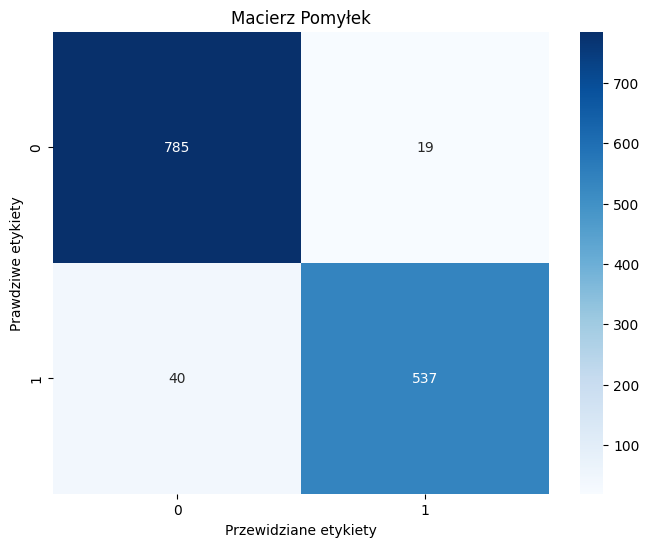

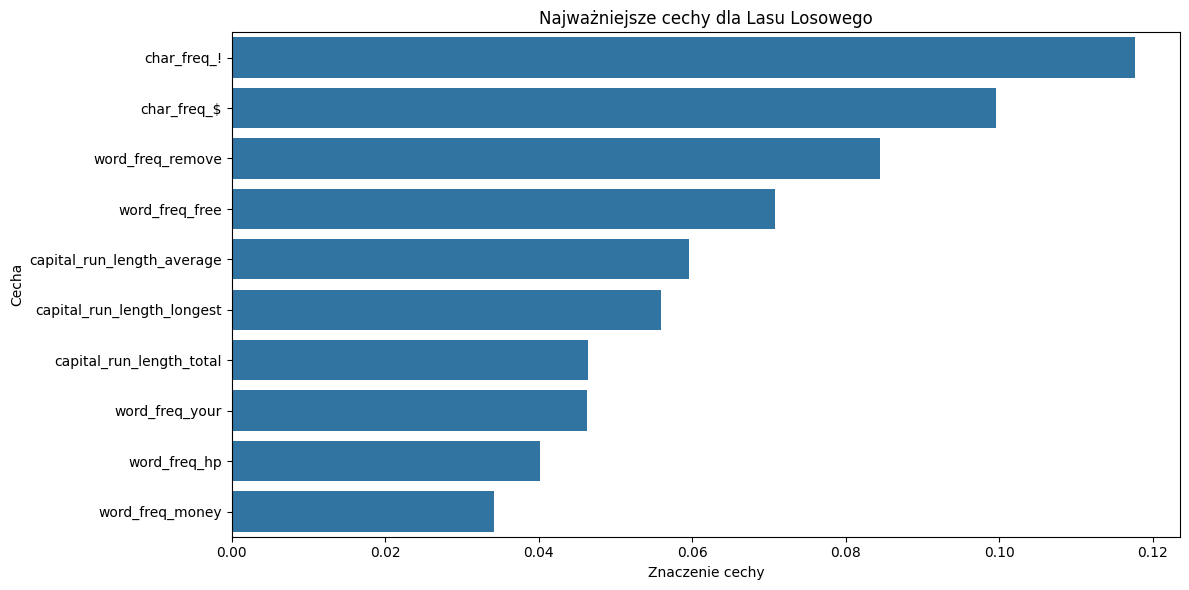


--- Walidacja Krzyzowa ---
Scores: [0.97636186 0.97833237 0.99021223 0.99576972 0.90709222]
Mean roc_auc: 0.9696
Std Dev roc_auc: 0.0321


In [ ]:
#Las
from sklearn.ensemble import RandomForestClassifier

# -------------------- #
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

### ---tuning------------------------------
"""
param_grid = {
    'n_estimators': [50, 100, 200],           #Liczba drzew
    'max_depth': [10, 20, None],              #Max głębokość drzewa          mniejsza złożoność pojedynczych drzew
    'min_samples_split': [2, 5, 10],          #Min liczba próbek, do podziału wewn węzła
    'min_samples_leaf': [1, 2, 5],            #Min liczba próbek aby węzeł był stał sie lisciem
    'max_features': ['sqrt', 0.5, 0.7],       #liczba cech do rozważenia przy podziale
    'criterion': ['gini', 'entropy']
}
grid_search_dt = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, scoring="roc_auc", n_jobs=-1)
grid_search_dt.fit(X_train, y_train)
print(f"\nNajlepsze parametry dla Lasu Losowego: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik AUC dla Lasu Losowego: {grid_search_dt.best_score_:.4f}")
"""
### ---tuning------------------------------

# -------------------- #
evaluation(rf_clf)
evaluation_example(rf_clf)
#rf_clf = grid_search_dt.best_estimator_
#evaluation(rf_clf)

# -------------------- #
importance = rf_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10)) # Pokaż top 10
plt.title('Najważniejsze cechy dla Lasu Losowego')
plt.xlabel('Znaczenie cechy')
plt.ylabel('Cecha')
plt.tight_layout()
plt.show()

# -------------------- #
validation(rf_clf, 'roc_auc')

--- Ocena ---
Accuracy: 0.9500
F1 Score: 0.9395
AUC: 0.9855

Classification Report
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       804
           1       0.95      0.93      0.94       577

    accuracy                           0.95      1381
   macro avg       0.95      0.95      0.95      1381
weighted avg       0.95      0.95      0.95      1381



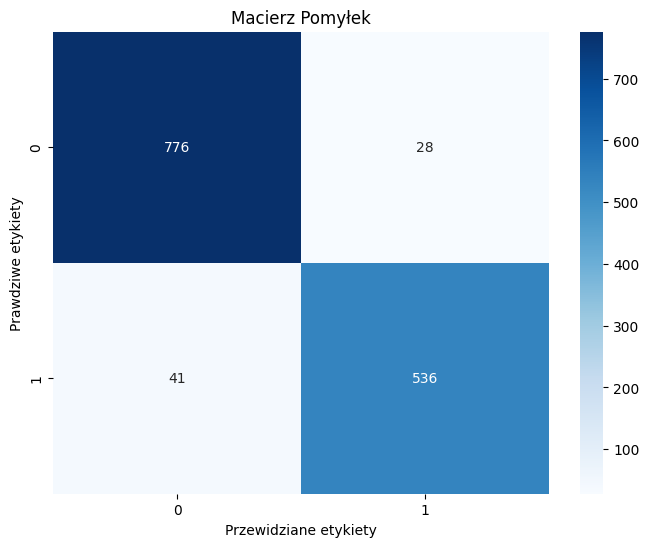


--- Walidacja Krzyzowa ---
Scores: [0.97599899 0.97898522 0.98079044 0.9932969  0.91718648]
Mean roc_auc: 0.9693
Std Dev roc_auc: 0.0267


In [ ]:
#SVM
from sklearn.svm import SVC

# -------------------- #
svm_clf = SVC(random_state=42, probability=True)
svm_clf.fit(X_train, y_train)

### ---tuning------------------------------
"""
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],       #Parametr regularyzacji
    'gamma': [0.001, 0.01, 0.1, 1],     #nie chce mi sie juz
    'kernel': ['linear', 'rbf']         #
}
grid_search_dt = GridSearchCV(SVC(random_state=42), param_grid, scoring="roc_auc", n_jobs=-1)
grid_search_dt.fit(X_train, y_train)
print(f"\nNajlepsze parametry dla SVM: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik AUC dla SVM: {grid_search_dt.best_score_:.4f}")
"""
### ---tuning------------------------------

# -------------------- #
evaluation(svm_clf)
evaluation_example(svm_clf)
#svm_clf = grid_search_dt.best_estimator_
#evaluation(svm_clf)

# -------------------- #
validation(svm_clf, 'roc_auc')


Najlepsze parametry dla KNN: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
Najlepszy wynik AUC dla KNN: 0.9799
--- Ocena ---
Accuracy: 0.9341
F1 Score: 0.9202
AUC: 0.9738

Classification Report
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       804
           1       0.93      0.91      0.92       577

    accuracy                           0.93      1381
   macro avg       0.93      0.93      0.93      1381
weighted avg       0.93      0.93      0.93      1381



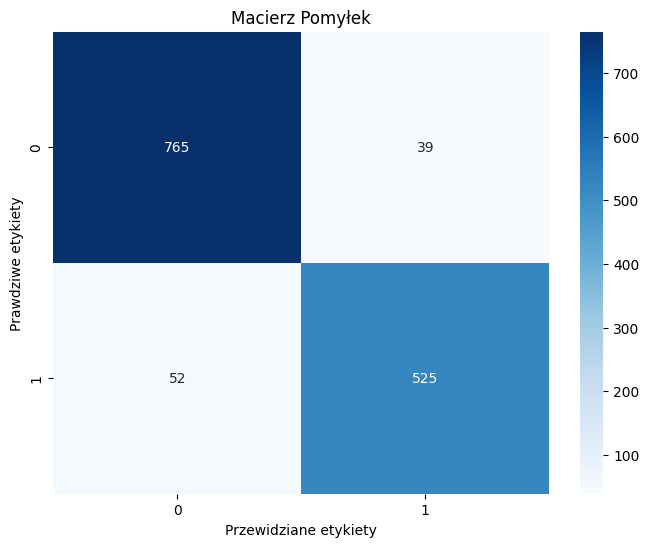

--- Ocena ---
Accuracy: 0.9406
F1 Score: 0.9260
AUC: 0.9846

Classification Report
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       804
           1       0.97      0.89      0.93       577

    accuracy                           0.94      1381
   macro avg       0.95      0.93      0.94      1381
weighted avg       0.94      0.94      0.94      1381



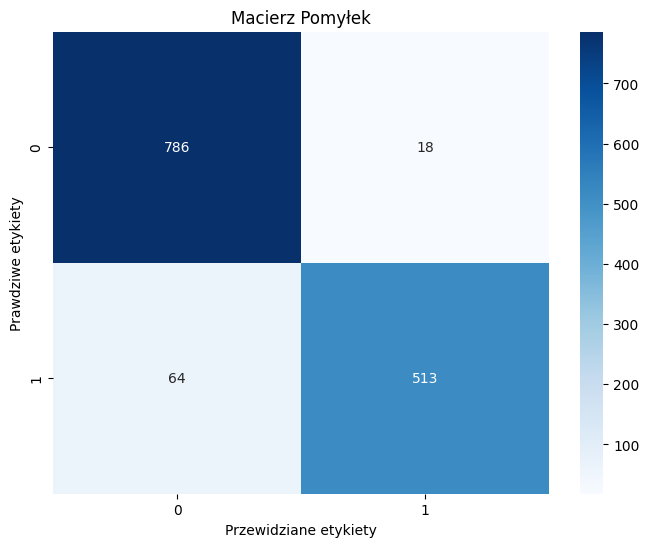


--- Walidacja Krzyzowa ---
Scores: [0.9686059  0.97221934 0.98439347 0.98699974 0.90531248]
Mean roc_auc: 0.9635
Std Dev roc_auc: 0.0299


In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

# -------------------- #
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)

### ---tuning------------------------------
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_dt = GridSearchCV(KNeighborsClassifier(), param_grid, scoring="roc_auc", n_jobs=-1)
grid_search_dt.fit(X_train, y_train)
print(f"\nNajlepsze parametry dla KNN: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik AUC dla KNN: {grid_search_dt.best_score_:.4f}")
### ---tuning------------------------------

# -------------------- #
evaluation(knn_clf)
evaluation_example(knn_clf)
knn_clf = grid_search_dt.best_estimator_
evaluation(knn_clf)
evaluation_example(knn_clf)

# -------------------- #
validation(knn_clf, 'roc_auc')

--- Ocena ---
Accuracy: 0.9522
F1 Score: 0.9418
AUC: 0.9891

Classification Report
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       804
           1       0.96      0.93      0.94       577

    accuracy                           0.95      1381
   macro avg       0.95      0.95      0.95      1381
weighted avg       0.95      0.95      0.95      1381



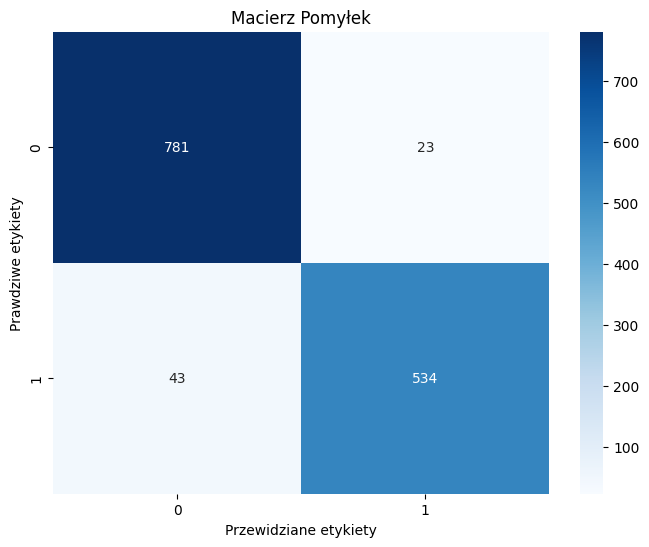


--- Walidacja Krzyzowa ---
Scores: [0.97941537 0.98200711 0.9882339  0.99515832 0.92137468]
Mean roc_auc: 0.9732
Std Dev roc_auc: 0.0265


In [ ]:
from sklearn.ensemble import VotingClassifier

# -------------------- #
estimators = [
    ('dt', dt_clf),
    ('rf', rf_clf),
    ('svm', svm_clf),
    ('knn', knn_clf)
]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

# -------------------- #
evaluation(voting_clf)
evaluation_example(voting_clf)

# -------------------- #
validation(voting_clf, 'roc_auc')

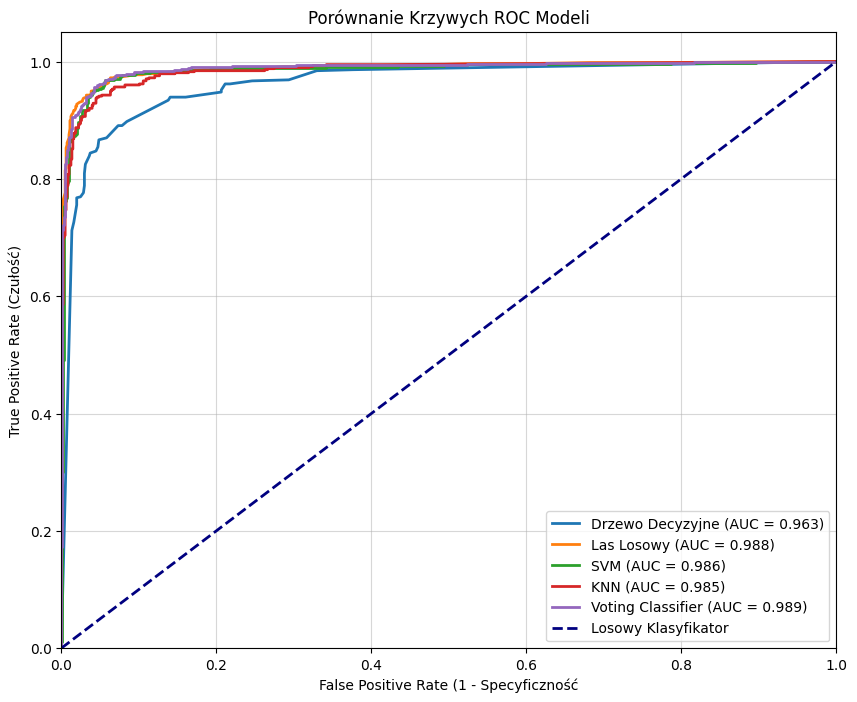

Text(0, 0.5, 'AUC')

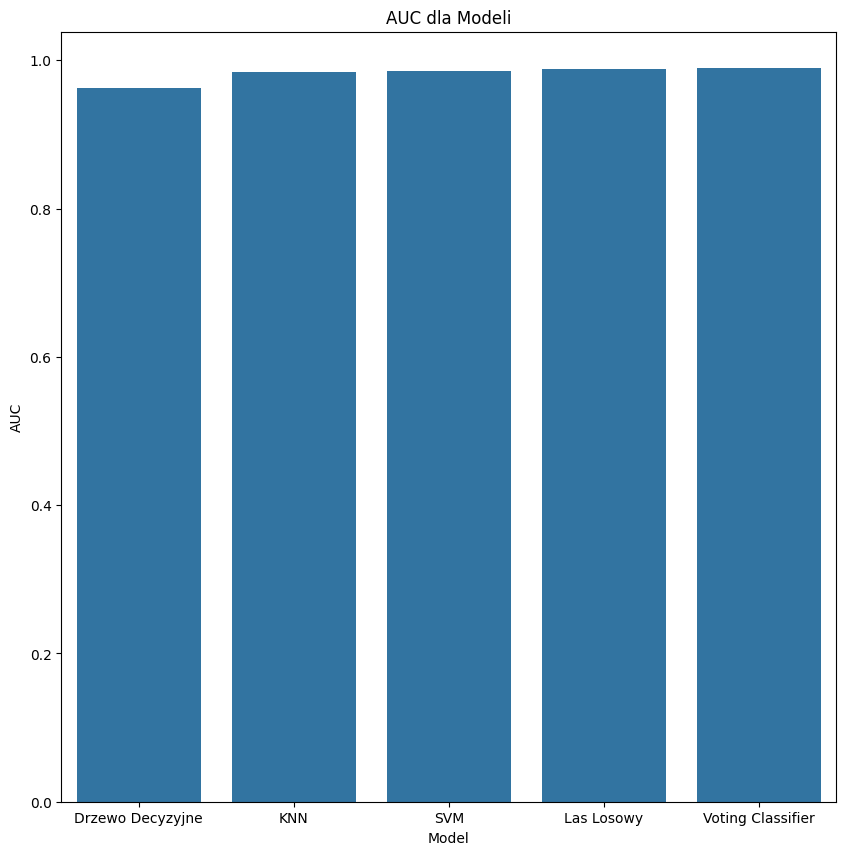

In [ ]:
# Krzywe ROC
def get_roc_data(model, X_test_data, y_true_data):
    proba = model.predict_proba(X_test_data)[:, 1]
    auc_score = roc_auc_score(y_true_data, proba)
    fpr, tpr, _ = roc_curve(y_true_data, proba)
    return fpr, tpr, auc_score

models_for_roc = {
    "Drzewo Decyzyjne": dt_clf,
    "Las Losowy": rf_clf,
    "SVM": svm_clf,
    "KNN": knn_clf,
    "Voting Classifier": voting_clf
}

roc_plot_data = []
for name, model_instance in models_for_roc.items():
    fpr, tpr, auc_val = get_roc_data(model_instance, X_test, y_test)
    roc_plot_data.append({'fpr': fpr, 'tpr': tpr, 'auc': auc_val, 'name': name})

plt.figure(figsize=(10, 8))
for data in roc_plot_data:
    plt.plot(data['fpr'], data['tpr'], lw=2, label=f"{data['name']} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy Klasyfikator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specyficzność')
plt.ylabel('True Positive Rate (Czułość)')
plt.title('Porównanie Krzywych ROC Modeli')
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.show()

# Słupkowy AUC
auc_scores = {data['name']: data['auc'] for data in roc_plot_data}
bar_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'AUC']).sort_values('AUC')

plt.figure(figsize=(10, 10))
sns.barplot(x='Model', y='AUC', data=bar_df)
plt.title('AUC dla Modeli')
plt.xlabel('Model')
plt.ylabel('AUC')